# Document Capture — Perspective Correction (classic CV)

Biến ảnh tài liệu chụp góc lệch → ảnh phẳng như scan, bằng OpenCV thuần (không deep learning).

## Bài học từ thực nghiệm trên 4 ảnh thật

Pipeline edge-based kinh điển (Canny → contour → 4-góc) **thất bại cả 4 ảnh** vì:
- `len(approx)==4` quá cứng: approxPolyDP nhảy số đỉnh không liên tục (9→6→2), hiếm khi rơi đúng 4.
- Lấy contour to nhất ⇒ bắt nhầm nền khi cảnh phức tạp (đèn trần, khung cửa).
- Biên đứt gãy (tương phản thấp, vật bị che) ⇒ không có contour lớn khép kín.

**Không có một bộ tham số edge nào robust cho mọi ảnh** — ảnh biên đứt cần nối mạnh, ảnh nền nhiễu cần nối yếu (mâu thuẫn).

### Giải pháp: 3 chiến lược segmentation, chọn theo loại ảnh

| METHOD | Tách document bằng | Hợp với | Kết quả thực tế |
|--------|--------------------|---------|------------------|
| `'edge'` | Biên Canny | Giấy phẳng, nền tương phản đều, chụp gần thẳng | Tốt cho ảnh "sạch" |
| `'saturation'` | Độ bão hoà (S) | Document **trắng/xám** trên nền **màu** | doc_3: bám tốt 3 cạnh (đáy lệch nếu bị che) |
| `'value'` | Độ sáng (V) | Document **sáng** trên nền **tối** (màn hình, slide) | doc_4: **warp phẳng tốt** |

**Giới hạn classic** (xác nhận bằng thực nghiệm): foreshortening cực mạnh + lẫn nền (doc_1) hoặc document nhỏ giữa cảnh nhiễu (doc_2) → **không method nào giải được**. Khi đó chỉ còn cách nhập tay 4 góc (xem cell cuối).

In [139]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def show(images, titles=None, figsize=(16, 8)):
    if not isinstance(images, list):
        images, titles = [images], [titles or '']
    titles = titles or [''] * len(images)
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    if len(images) == 1:
        axes = [axes]
    for ax, im, t in zip(axes, images, titles):
        ax.imshow(im if im.ndim == 2 else cv2.cvtColor(im, cv2.COLOR_BGR2RGB),
                  cmap='gray' if im.ndim == 2 else None)
        ax.set_title(t, fontsize=12)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Bước 1 — Load ảnh + cấu hình

Downscale về `WORK_H` (600px) trước khi xử lý: nhanh hơn, và làm mượt nhiễu chi tiết (text, vân giấy) — ta chỉ cần biên ngoài của document. Toạ độ quad sẽ scale ngược về ảnh gốc khi warp để giữ độ phân giải.

Gốc: 576×1280  →  xử lý ở: 270×600


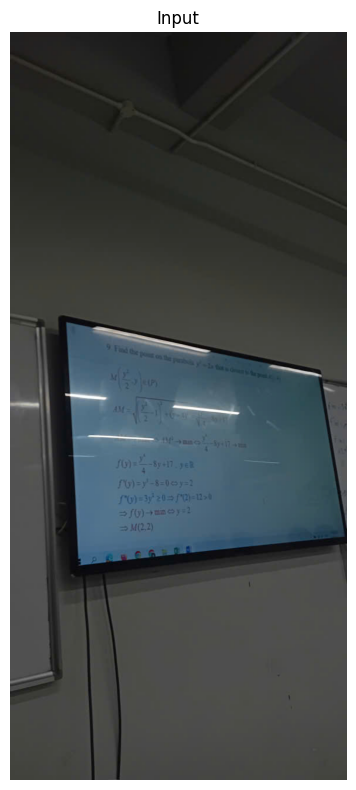

In [140]:
IMG_PATH = r'../image/doc_4.jpeg'   # <-- ảnh của bạn
METHOD   = 'edge'                  # 'edge' | 'saturation' | 'value'  (xem Bước 2 để chọn)
WORK_H   = 600

img = cv2.imread(IMG_PATH)
assert img is not None, f'Không load được ảnh: {IMG_PATH}'
H, W  = img.shape[:2]
scale = WORK_H / H
small = cv2.resize(img, (int(W * scale), WORK_H))
print(f'Gốc: {W}×{H}  →  xử lý ở: {small.shape[1]}×{small.shape[0]}')
show(img, 'Input')

## Bước 2 — Tạo mask document (3 chiến lược)

**Tại sao 3 cách thay vì chỉ edge?** Document không có đặc trưng cố định — giấy trắng, màn hình sáng, slide... Mỗi loại tách tốt nhất bằng kênh khác nhau:

- **edge**: `bilateralFilter` (giữ biên, xoá texture) → Canny ngưỡng tự động theo `median` → `MORPH_CLOSE` nối biên đứt. Dùng khi biên document sắc nét với nền.
- **saturation**: nền màu (cam, gỗ) có **S cao**, giấy trắng/xám có **S thấp** → ngưỡng Otsu trên kênh S tách sạch. Đây là chìa khoá cho doc_3 (edge thất bại vì biên trắng-cam bị blur làm đứt).
- **value**: màn hình/slide **sáng** (V cao) trên tường/viền **tối** (V thấp) → Otsu trên kênh V. Chìa khoá cho doc_4.

**Otsu tự chọn ngưỡng** tối ưu (cực tiểu variance nội nhóm) — không cần hard-code. Heuristic `mean > 127 → đảo` đảm bảo *document = vùng trắng (255)* trong mask, bất kể nó sáng hay tối hơn nền.

`CLOSE (15×15)` lấp lỗ hổng bên trong document (text, logo); `OPEN (9×9)` xoá đốm nhiễu rời rạc ngoài document.

METHOD=edge  fill=1.9%


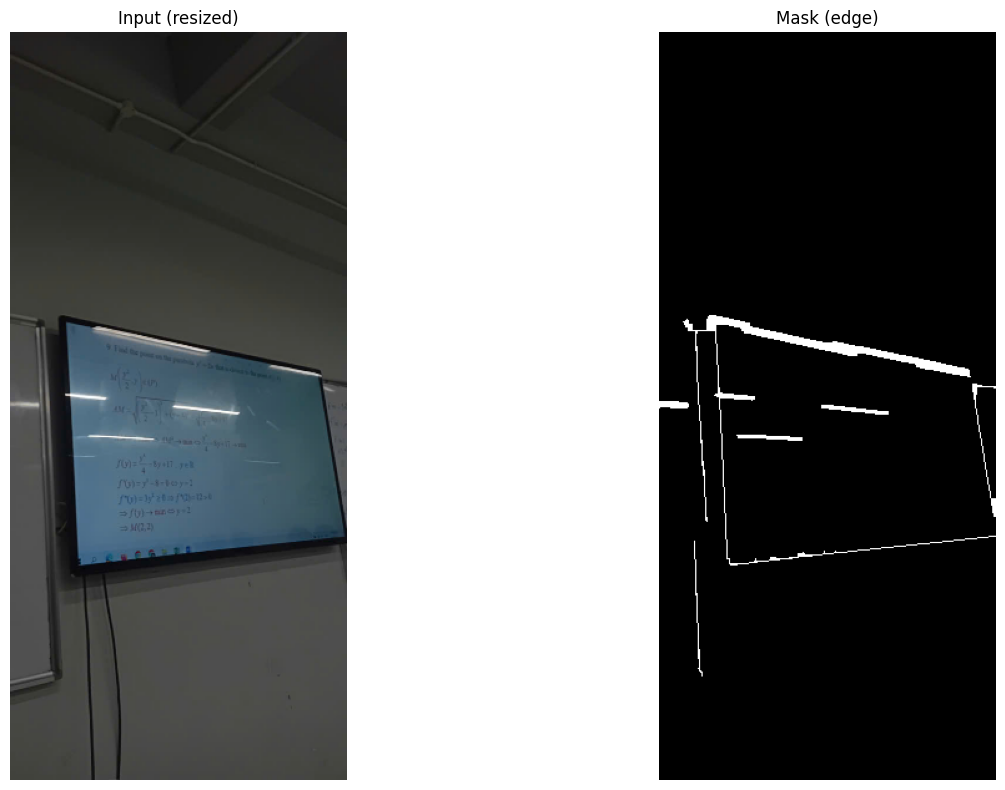

In [141]:
def auto_canny(gray, sigma=0.33):
    v = float(np.median(gray))
    return cv2.Canny(gray, int(max(0, (1 - sigma) * v)), int(min(255, (1 + sigma) * v)))

def build_mask(small, method):
    """Trả về mask nhị phân (document = 255)."""
    if method == 'edge':
        gray  = cv2.bilateralFilter(cv2.cvtColor(small, cv2.COLOR_BGR2GRAY), 9, 75, 75)
        edges = auto_canny(gray)
        return cv2.morphologyEx(edges, cv2.MORPH_CLOSE,
                                cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7)))
    # saturation / value: Otsu trên kênh HSV tương ứng
    hsv = cv2.cvtColor(small, cv2.COLOR_BGR2HSV)
    ch  = hsv[:, :, 1] if method == 'saturation' else hsv[:, :, 2]
    _, mask = cv2.threshold(ch, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if mask.mean() > 127:                       # đảm bảo document là vùng 255 (nhỏ hơn nền)
        _, mask = cv2.threshold(ch, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((15, 15), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  np.ones((9, 9),  np.uint8))
    return mask

mask = build_mask(small, METHOD)
print(f"METHOD={METHOD}  fill={mask.mean()/255*100:.1f}%")
show([small, mask], ['Input (resized)', f'Mask ({METHOD})'])

### So sánh nhanh 3 method (chọn bằng mắt)

Auto-chọn method bằng score **không đáng tin** (thực nghiệm: quad nền/full-frame thắng giả vì rectangularity≈1). Thay vào đó, render cả 3 cạnh nhau — bạn nhìn cái nào bám đúng document rồi đặt `METHOD` ở Bước 1.

edge       : score=-1.000  NONE
saturation : score=0.667  quad
value      : score=0.646  quad


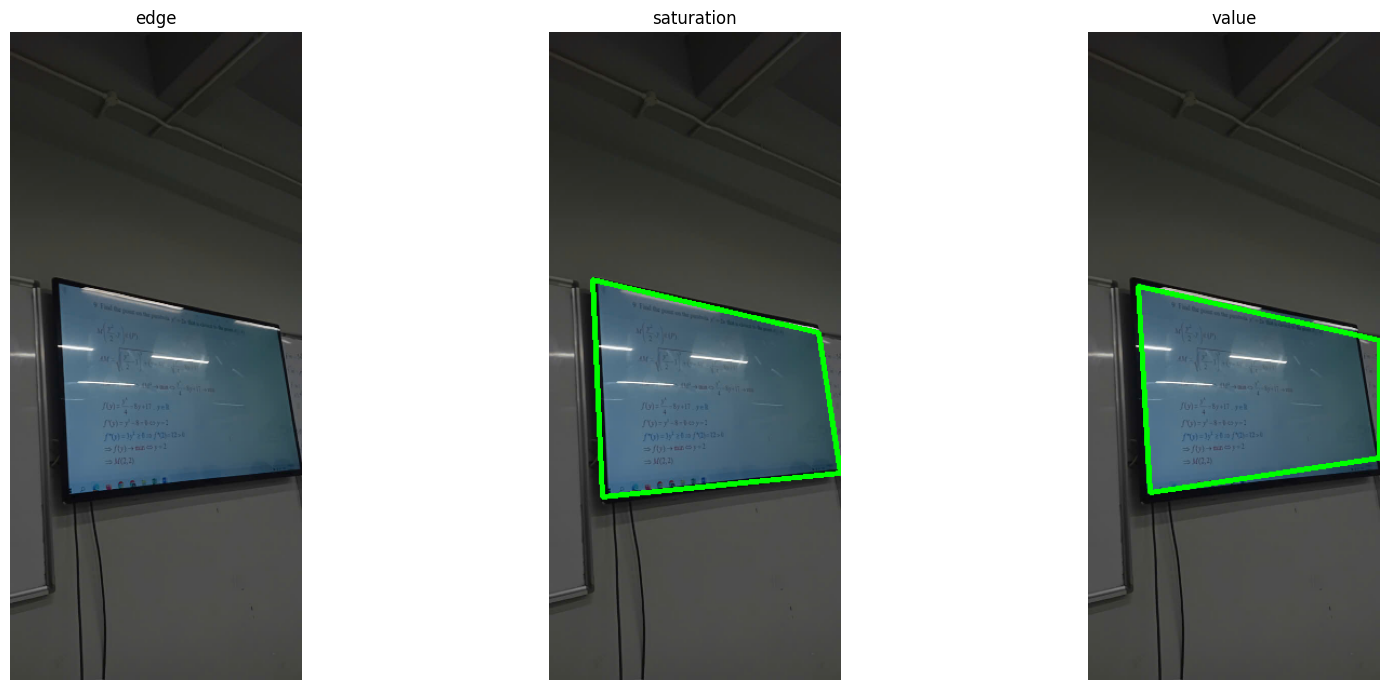

In [142]:
def order_quad(pts):
    pts = pts.reshape(4, 2).astype(np.float32)
    s, d = pts.sum(1), np.diff(pts, 1).flatten()
    return np.array([pts[s.argmin()], pts[d.argmin()],
                     pts[s.argmax()], pts[d.argmax()]], dtype=np.float32)

def quad_from_contour(c):
    """Quét nhiều epsilon → ưu tiên 4 góc convex; fallback minAreaRect (luôn 4 góc)."""
    peri = cv2.arcLength(c, True)
    for f in np.linspace(0.01, 0.10, 19):
        ap = cv2.approxPolyDP(c, f * peri, True)
        if len(ap) == 4 and cv2.isContourConvex(ap):
            return ap.reshape(4, 2).astype(np.float32)
    return cv2.boxPoints(cv2.minAreaRect(c)).astype(np.float32)

def score_quad(quad, shape):
    H, W = shape[:2]
    area = cv2.contourArea(quad)
    if area < 0.04 * H * W or area > 0.90 * H * W:        # nhiễu nhỏ / full-frame
        return -1.0
    mx, my = 0.02 * W, 0.02 * H                            # góc dính sát mép = full-frame
    if sum((px < mx or px > W-mx) and (py < my or py > H-my) for px, py in quad) >= 3:
        return -1.0
    rect_area = cv2.contourArea(cv2.boxPoints(cv2.minAreaRect(quad)))
    rectangularity = area / rect_area if rect_area > 0 else 0.0
    cx, cy = quad.mean(0) / [W, H]
    return 0.55 * rectangularity + 0.25 * (area/(H*W)) + 0.20 * (1 - abs(cx-.5) - abs(cy-.5))

def find_quad(mask, shape):
    """Contour lớn → convexHull (làm phẳng răng cưa) → quad điểm cao nhất."""
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    best, best_s = None, -1.0
    for c in cnts:
        if cv2.contourArea(c) < 0.04 * shape[0] * shape[1]:
            continue
        q = quad_from_contour(cv2.convexHull(c))
        s = score_quad(q, shape)
        if s > best_s:
            best, best_s = q, s
    return (order_quad(best), best_s) if best is not None else (None, best_s)

tiles = []
for m in ['edge', 'saturation', 'value']:
    q, sc = find_quad(build_mask(small, m), small.shape)
    vis = small.copy()
    if q is not None:
        cv2.polylines(vis, [q.astype(np.int32).reshape(-1, 1, 2)], True, (0, 255, 0), 3)
    tiles.append(vis)
    print(f"{m:11s}: score={sc:.3f}  {'quad' if q is not None else 'NONE'}")
show(tiles, ['edge', 'saturation', 'value'], figsize=(18, 7))

## Bước 3 — Tìm 4 góc document

Cải tiến so với pipeline cũ (đã giải thích ở các hàm trên):

1. **`convexHull` trước `approxPolyDP`** — làm phẳng răng cưa do dây điện/viền (doc_4), giúp ra tứ giác sạch.
2. **Quét 19 epsilon** thay vì ép `==4` ở một epsilon — ưu tiên 4-góc-convex đầu tiên tìm được; nếu không có, **fallback `minAreaRect`** (luôn cho 4 góc, tốt khi foreshortening nhẹ).
3. **Scoring thay `MIN_AREA_RATIO`**: `rectangularity` (độ giống hình chữ nhật) + diện tích + gần tâm. Loại quad quá nhỏ, **full-frame** (>90% hoặc ≥3 góc dính mép — chính là bẫy làm pipeline bắt nhầm nền).

In [143]:
quad_small, score = find_quad(mask, small.shape)
assert quad_small is not None, (
    f'Không tìm được document với METHOD={METHOD!r}. '
    'Thử method khác (xem cell so sánh) hoặc nhập tay 4 góc ở cell cuối.')

quad = quad_small / scale          # scale ngược về toạ độ ảnh GỐC
print(f'score={score:.3f}\nquad (gốc):\n{quad}')

vis = img.copy()
cv2.polylines(vis, [quad.astype(np.int32).reshape(-1, 1, 2)], True, (0, 255, 0), 4)
for i, pt in enumerate(quad):
    cv2.circle(vis, tuple(pt.astype(int)), 12, (0, 0, 255), -1)
    cv2.putText(vis, ['TL','TR','BR','BL'][i], tuple(pt.astype(int)),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 255), 3)
show(vis, f'4 góc ({METHOD})', figsize=(9, 9))

AssertionError: Không tìm được document với METHOD='edge'. Thử method khác (xem cell so sánh) hoặc nhập tay 4 góc ở cell cuối.

## Bước 4 — Perspective Transform

`warpAffine` (3 điểm) chỉ làm được rotation/scale/shear — không sửa được phối cảnh (document nghiêng tạo **hình thang**, không phải hình bình hành). Cần homography 3×3 từ 4 cặp điểm:

- `getPerspectiveTransform(src, dst)` giải hệ 8 ẩn từ 4 cặp góc.
- `OUT_W/OUT_H` = max của 2 cạnh đối diện → giữ kích thước tự nhiên, không méo tỉ lệ.

Output: 557×362


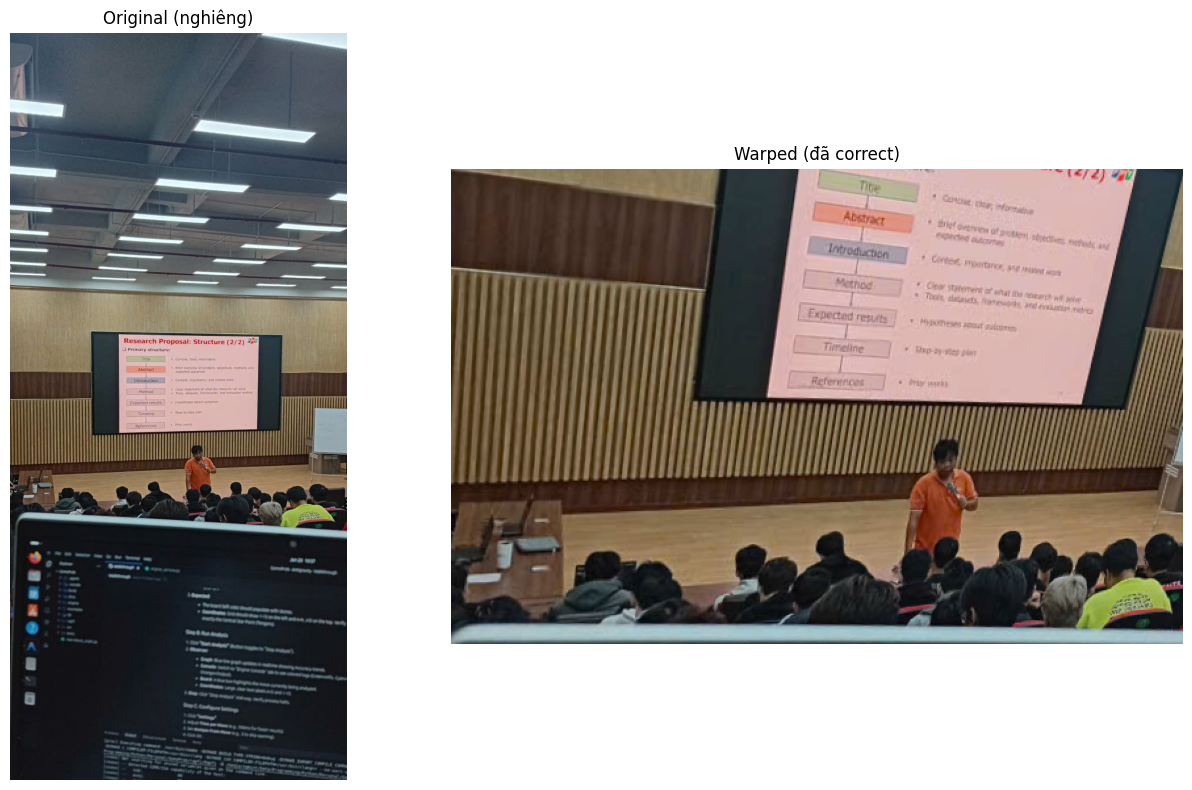

In [ ]:
tl, tr, br, bl = quad
OUT_W = int(max(np.linalg.norm(tr - tl), np.linalg.norm(br - bl)))
OUT_H = int(max(np.linalg.norm(bl - tl), np.linalg.norm(br - tr)))

dst = np.array([[0, 0], [OUT_W-1, 0], [OUT_W-1, OUT_H-1], [0, OUT_H-1]], dtype=np.float32)
M       = cv2.getPerspectiveTransform(quad, dst)
warped  = cv2.warpPerspective(img, M, (OUT_W, OUT_H))

print(f'Output: {OUT_W}×{OUT_H}')
show([img, warped], ['Original (nghiêng)', 'Warped (đã correct)'], figsize=(14, 8))

## Bước 5 — Enhance (tùy chọn)

- **A. Adaptive threshold** → đen trắng kiểu scan. Với mỗi vùng 21×21, ngưỡng = mean − 10 ⇒ tự loại shadow (ngưỡng adapt theo độ sáng cục bộ). Tốt cho in/OCR.
- **B. CLAHE** trên kênh L (LAB) → giữ màu, tăng contrast đều theo tile 8×8, không over-amplify noise.

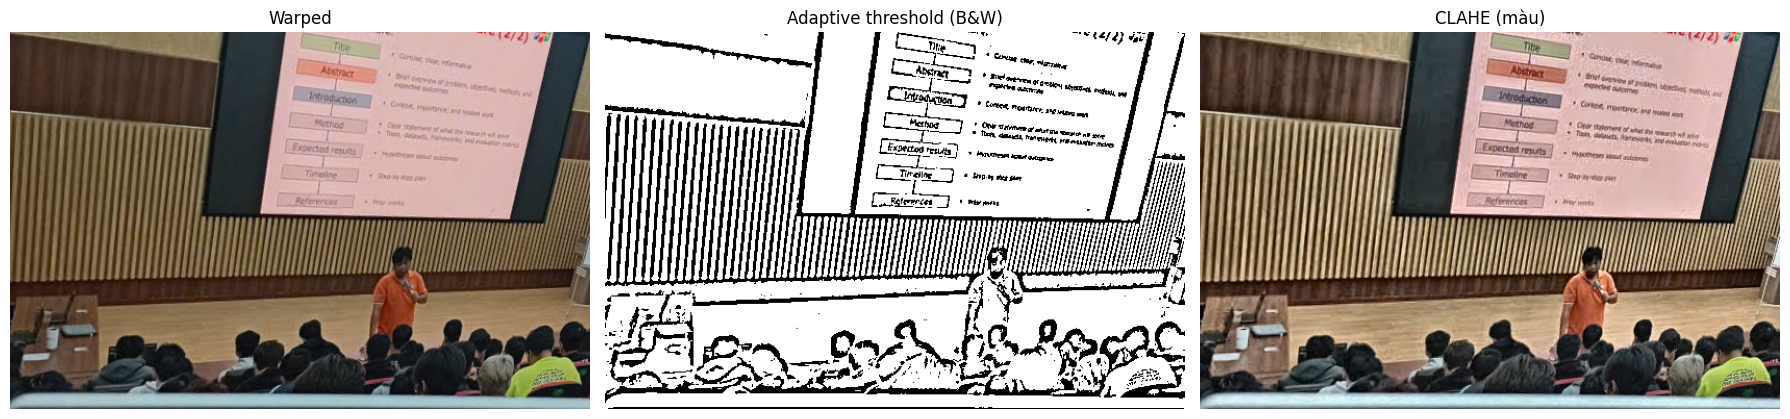

In [ ]:
gray_w = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
scan_bw = cv2.adaptiveThreshold(gray_w, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv2.THRESH_BINARY, 21, 10)

lab = cv2.cvtColor(warped, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
l = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(l)
scan_color = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)

show([warped, scan_bw, scan_color],
     ['Warped', 'Adaptive threshold (B&W)', 'CLAHE (màu)'], figsize=(18, 6))

In [ ]:
from datetime import datetime
ts  = datetime.now().strftime('%Y%m%d-%H%M%S')
out = Path('../image'); out.mkdir(exist_ok=True)
cv2.imwrite(str(out / f'{ts}_warped.png'),     warped)
cv2.imwrite(str(out / f'{ts}_scan_bw.png'),    scan_bw)
cv2.imwrite(str(out / f'{ts}_scan_color.png'), scan_color)
print(f'Saved image/{ts}_*.png')

Saved image/20260612-142413_*.png


## Fallback — Nhập tay 4 góc (khi auto thất bại)

Với ảnh ngoài tầm classic (foreshortening cực mạnh + lẫn nền như doc_1; document nhỏ giữa cảnh nhiễu như doc_2), không method tự động nào đúng. Khi đó: mở ảnh, đọc toạ độ pixel 4 góc (thứ tự **TL, TR, BR, BL**) rồi điền vào đây — phần warp ở Bước 4 dùng lại y nguyên.

Đây cũng là cơ chế các app scan thật dùng: auto-detect làm gợi ý, người dùng kéo chỉnh 4 góc.

In [ ]:
# Bỏ comment + điền toạ độ (x, y) trên ẢNH GỐC để override auto-detection:
# quad = np.array([
#     [ 120,  80],   # TL
#     [ 900,  60],   # TR
#     [ 950, 1180],  # BR
#     [  80, 1150],  # BL
# ], dtype=np.float32)
#
# tl, tr, br, bl = quad
# OUT_W = int(max(np.linalg.norm(tr-tl), np.linalg.norm(br-bl)))
# OUT_H = int(max(np.linalg.norm(bl-tl), np.linalg.norm(br-tr)))
# dst = np.array([[0,0],[OUT_W-1,0],[OUT_W-1,OUT_H-1],[0,OUT_H-1]], dtype=np.float32)
# warped = cv2.warpPerspective(img, cv2.getPerspectiveTransform(quad, dst), (OUT_W, OUT_H))
# show([img, warped], ['Original', 'Warped (manual corners)'], figsize=(14, 8))

## Tổng kết — kết quả thực tế trên 4 ảnh test

| Ảnh | Nội dung | METHOD đúng | Kết quả |
|-----|----------|-------------|---------|
| doc_4 | Màn hình treo tường | `value` | ✅ Detect + warp phẳng tốt |
| doc_3 | Bìa sách trắng / nền cam | `saturation` | ⚠️ Bám 3 cạnh; đáy lệch do quần che (S thấp dính vào bìa) → warp méo phần đáy |
| doc_1 | Bìa sách nghiêng, nền thư viện | — | ❌ Foreshortening cực mạnh + lẫn nền → dùng fallback thủ công |
| doc_2 | Slide giữa giảng đường | — | ❌ Document nhỏ giữa cảnh nhiễu → dùng fallback thủ công |

**Quy trình dùng:**
1. Set `IMG_PATH`, chạy tới cell **So sánh 3 method**.
2. Nhìn xem method nào bám đúng document → đặt `METHOD` ở Bước 1, chạy tiếp.
3. Nếu cả 3 đều sai → dùng cell **Nhập tay 4 góc**.

**Cải tiến đã áp dụng vs pipeline cũ:** auto-Canny theo median · 3 chiến lược mask (edge/S/V) · convexHull · quét 19 epsilon + fallback minAreaRect · scoring (rectangularity + area + center) thay ngưỡng area cứng · guard full-frame.

**Giới hạn cốt lõi:** edge/threshold-based luôn fragile khi document không tách bạch khỏi nền (foreshortening, che khuất, cảnh lộn xộn). Muốn robust hơn cần deep segmentation hoặc thao tác kéo góc tương tác.